In [495]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [496]:
df = pd.read_excel('lophoc.xlsx')
df.head()

,Sức khỏe,Thời tiết,Kết quả
0,ốm,u ám,nghỉ
1,ốm,mưa,nghỉ
2,ốm,nắng,nghỉ
3,ốm,u ám,học
4,tốt,u ám,học


In [497]:
x = pd.DataFrame(df.iloc[:,:-1])
y = pd.DataFrame(df.iloc[:,-1])

In [498]:
from sklearn.preprocessing import LabelEncoder
encHealth = LabelEncoder()
x['Sức khỏe'] = encHealth.fit_transform(x['Sức khỏe'])
encWeather = LabelEncoder()
x['Thời tiết'] = encWeather.fit_transform(x['Thời tiết'])

In [499]:
y

,Kết quả
0,nghỉ
1,nghỉ
2,nghỉ
3,học
4,học
5,học
6,nghỉ


In [500]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=31)

In [501]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(5, 2)
(2, 2)
(5, 1)
(2, 1)


In [502]:
x_train

,Sức khỏe,Thời tiết
4,0,2
3,1,2
6,0,1
0,1,2
2,1,1


In [503]:
y_train

,Kết quả
4,học
3,học
6,nghỉ
0,nghỉ
2,nghỉ


In [504]:
from sklearn.tree import DecisionTreeClassifier
modeIDT = DecisionTreeClassifier (criterion='entropy',max_depth=3)
#train
modeIDT = modeIDT.fit(x_train,y_train)

[Text(0.4, 0.8333333333333334, 'Thời tiết <= 1.5\nentropy = 0.971\nsamples = 5\nvalue = [2, 3]\nclass = nghỉ'),
 Text(0.2, 0.5, 'entropy = 0.0\nsamples = 2\nvalue = [0, 2]\nclass = nghỉ'),
 Text(0.6, 0.5, 'Sức khỏe <= 0.5\nentropy = 0.918\nsamples = 3\nvalue = [2, 1]\nclass = học'),
 Text(0.4, 0.16666666666666666, 'entropy = 0.0\nsamples = 1\nvalue = [1, 0]\nclass = học'),
 Text(0.8, 0.16666666666666666, 'entropy = 1.0\nsamples = 2\nvalue = [1, 1]\nclass = học')]

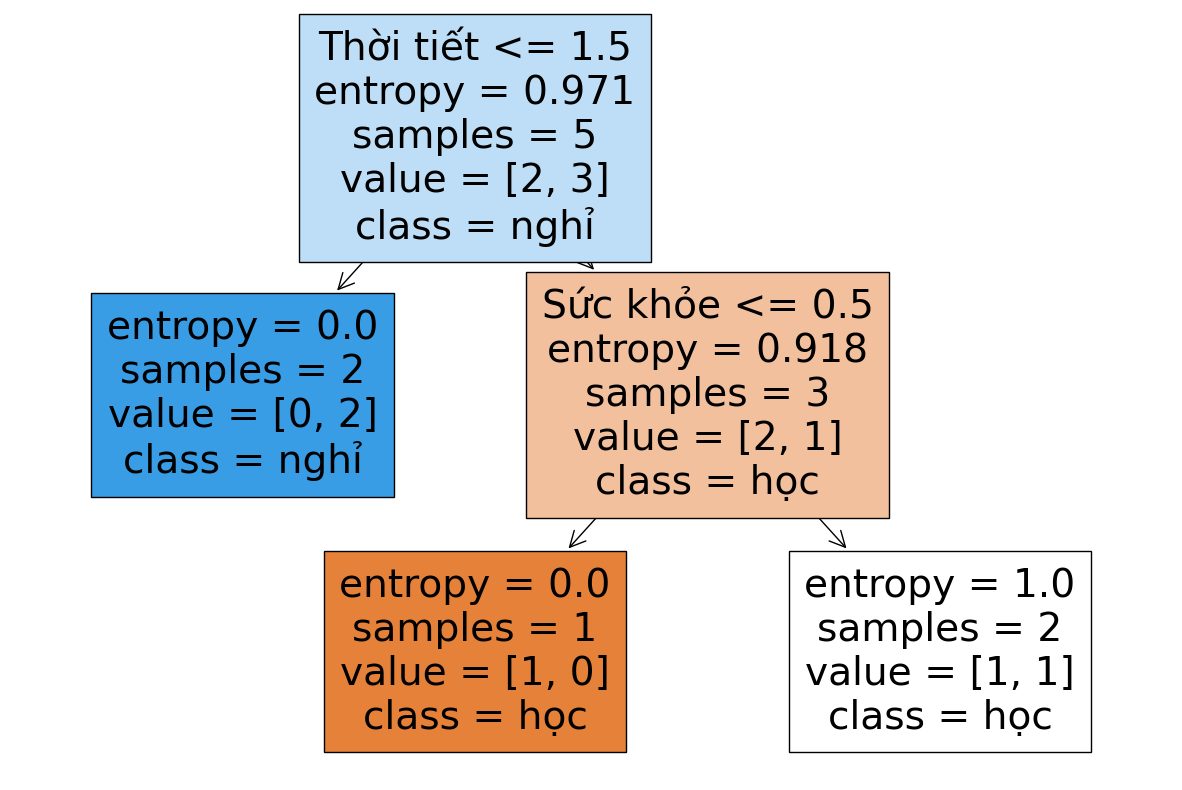

In [505]:
# Vẽ cây:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

feature_cols = x_train.columns

plt.figure(figsize=(15,10))
plot_tree(modeIDT, feature_names= feature_cols, class_names = modeIDT.classes_, filled = True)

### Information Gain (IG) là một hàm số biểu diễn mức độ giảm xuống của Entropy
    - Mức độ giảm càng cao, entropy mới càng thấp ⇒ dễ đưa ra quyết định.

In [506]:
from sklearn.metrics import accuracy_score
y_test_pred = modeIDT.predict(x_test)
print("acc", accuracy_score(y_test,y_test_pred))

acc 0.5


In [507]:
# Thực hiện k-fold cross-validation
from sklearn.model_selection import cross_val_score
scores = cross_val_score(modeIDT, x, y, cv=3)  # cv= 3 cho 3-fold cross-validation

In [508]:
# In ra độ chính xác trung bình
print(f"Độ chính xác trung bình: {scores.mean():.2f}")

Độ chính xác trung bình: 0.61


## Đối với data Boston.csv

In [509]:
import pandas as pd
df = pd.read_csv('boston.csv')
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [510]:
#Tập dữ liệu input (đặc trưng) và output (mục tiêu)
x = df.iloc[:]#feature
x = df.drop('CHAS', axis=1)
y = df['CHAS'] #
print('Input features: ', ', '.join(x))
print(x.shape)

Input features:  CRIM, ZN, INDUS, NOX, RM, AGE, DIS, RAD, TAX, PTRATIO, B, LSTAT, MEDV
(506, 13)


In [511]:
x

,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0


In [512]:
y

0      0
1      0
2      0
3      0
4      0
      ..
501    0
502    0
503    0
504    0
505    0
Name: CHAS, Length: 506, dtype: int64

In [513]:
# Split dataset into training set and test set
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=34) # 80% training and 30% test

In [514]:
modeIDT = DecisionTreeClassifier (criterion='entropy',max_depth=3)
#train
modeIDT = modeIDT.fit(X_train,y_train)

Để minh chứng cho nhận định trên, ta sẽ thử nghiệm dự báo cho 5 quan sát sao cho 
giá trị LSTAT = 10, RM = 6, DIS = 3 là cố định và những giá trị khác thay đổi ngẫu nhiên và kiểm tra kết quả dự báo.

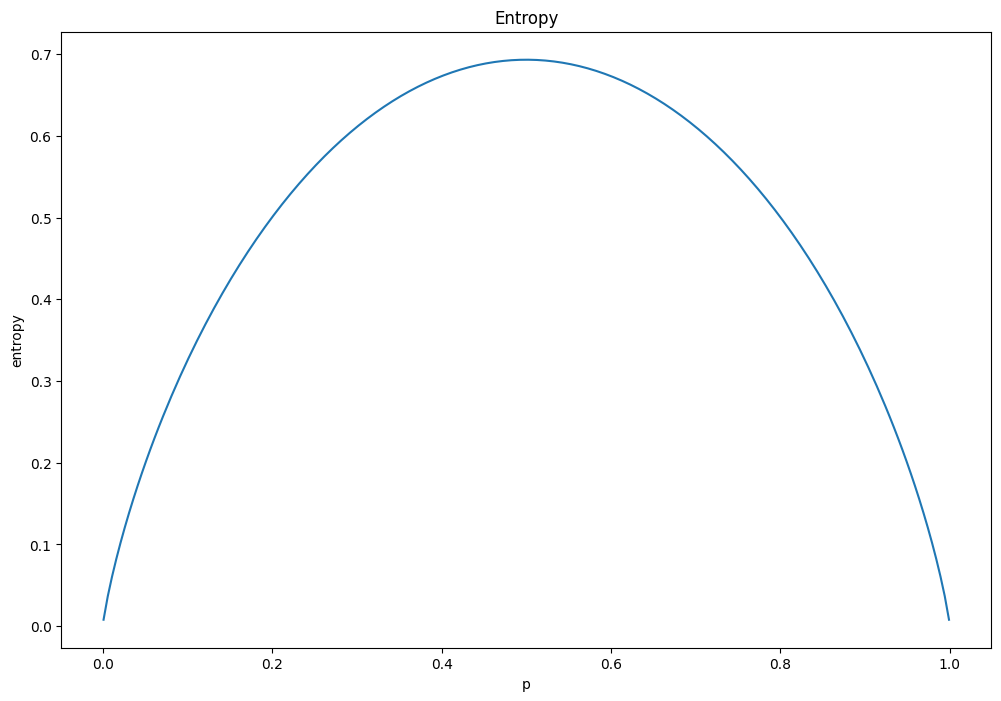

In [515]:
import numpy as np
import matplotlib.pyplot as plt

# Tính entropy theo p
def _entropy(p):
  return -(p*np.log(p)+(1-p)*np.log((1-p)))

# Khởi tạo gía trị yhat từ 0 đến 1
p = np.linspace(0.001, 0.999, 200)

# Hàm visualize cross entropy
def _plot_crs(p):
  entropy = _entropy(p)
  plt.figure(figsize = (12, 8))
  plt.plot(p, entropy)
  plt.xlabel('p')
  plt.ylabel('entropy')
  plt.title('Entropy')
  plt.show()

_plot_crs(p)

In [516]:
import numpy as np

def calculate_weights(y):
  """Tính toán trọng số cho các mẫu dữ liệu

  Args:
    y: Mảng chứa nhãn của các mẫu dữ liệu

  Returns:
    Mảng chứa trọng số tương ứng với mỗi mẫu
  """

  # Tính tần số của mỗi lớp
  unique_classes, class_counts = np.unique(y, return_counts=True)

  # Tính tổng số mẫu
  total_samples = len(y)

  # Tính trọng số cho mỗi mẫu dựa trên nghịch đảo tần số lớp
  weights = np.zeros(total_samples)
  for i, label in enumerate(y):
    class_index = np.where(unique_classes == label)[0][0]
    weights[i] = total_samples / class_counts[class_index]

  return weights

In [517]:
import numpy as np

def calculate_entropy(y):
    """Tính entropy của một tập hợp nhãn"""
    _, counts = np.unique(y, return_counts=True)
    probs = counts / len(y)
    return -np.sum(probs * np.log2(probs))

def calculate_information_gain(X, y, feature_index):
    """Tính Information Gain khi chia dữ liệu theo một thuộc tính"""
    unique_values = np.unique(X[:, feature_index])
    parent_entropy = calculate_entropy(y)
    weighted_entropy = 0
    for value in unique_values:
        subset = y[X[:, feature_index] == value]
        subset_entropy = calculate_entropy(subset)
        weighted_entropy += len(subset) / len(y) * subset_entropy
    return parent_entropy - weighted_entropy

# Ví dụ sử dụng
X = np.array([[1, 2], [1, 3], [2, 1], [2, 2]])  # Dữ liệu đầu vào
y = np.array([0, 0, 1, 1])  # Nhãn
information_gain = calculate_information_gain(X, y, 0)  # Tính Information Gain cho thuộc tính đầu tiên
print(information_gain)

1.0
